In [1]:
# Install required libraries
!pip install semopy
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 8.0 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=b1641270cb7cb47c0571b376f23aab8b7522c634f8eb6bb45b22e24d7a7f998a
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=e782c28450331ea6f2bba6cebef0299317a4a86412f17f566f7023d2b5814ec2
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built fac

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

from semopy import Model
from semopy import semplot

In [3]:
# Load dataset
data = pd.read_excel("/content/OTT_Responses_copy.xlsx")

# preview
data.head()

,Timestamp,D1,D2,D3,D4,CB4 (DO NOT USE),D5,CB5 (DO NOT USE),CB6,CB1,...,SM1,SM2,SM3,CD1,CD2,CD3,CD4,CI1,CI2,CI3
0,4/19/2025 22:37:31,2,2,2,7,"JioHotstar, SonyLIV, YouTube Premium",4,"Movies, TV Series/Web Series, Live Sports, Rea...",4,4,...,5,4,4,3,2,5,3,4,3,2
1,4/19/2025 23:43:51,6,2,3,5,"Netflix, YouTube Premium, Cruncyroll",4,"News, Live Sports",1,3,...,2,3,4,3,4,3,3,4,2,4
2,4/20/2025 10:09:27,2,1,4,4,Netflix,4,"Movies, TV Series/Web Series, Live Sports, Doc...",3,3,...,4,2,1,4,3,4,2,3,4,2
3,4/21/2025 12:50:23,6,2,2,3,"Netflix, Amazon Prime Video, JioHotstar, Zee5,...",3,"Movies, TV Series/Web Series, News, Documentar...",2,3,...,2,4,2,1,2,2,3,3,1,3
4,12/22/2025 21:38:16,6,1,4,6,"Netflix, Amazon Prime Video, JioHotstar, Zee5,...",1,"Movies, TV Series/Web Series, Documentaries",3,3,...,3,5,5,2,3,3,2,4,4,3


In [4]:
# Check missing values
data.isnull().sum()

# Fill missing values if any
data = data.fillna(data.mean(numeric_only=True))

# check shape
data.shape

(212, 41)

##Correlation Matrix (Important for CB-SEM)

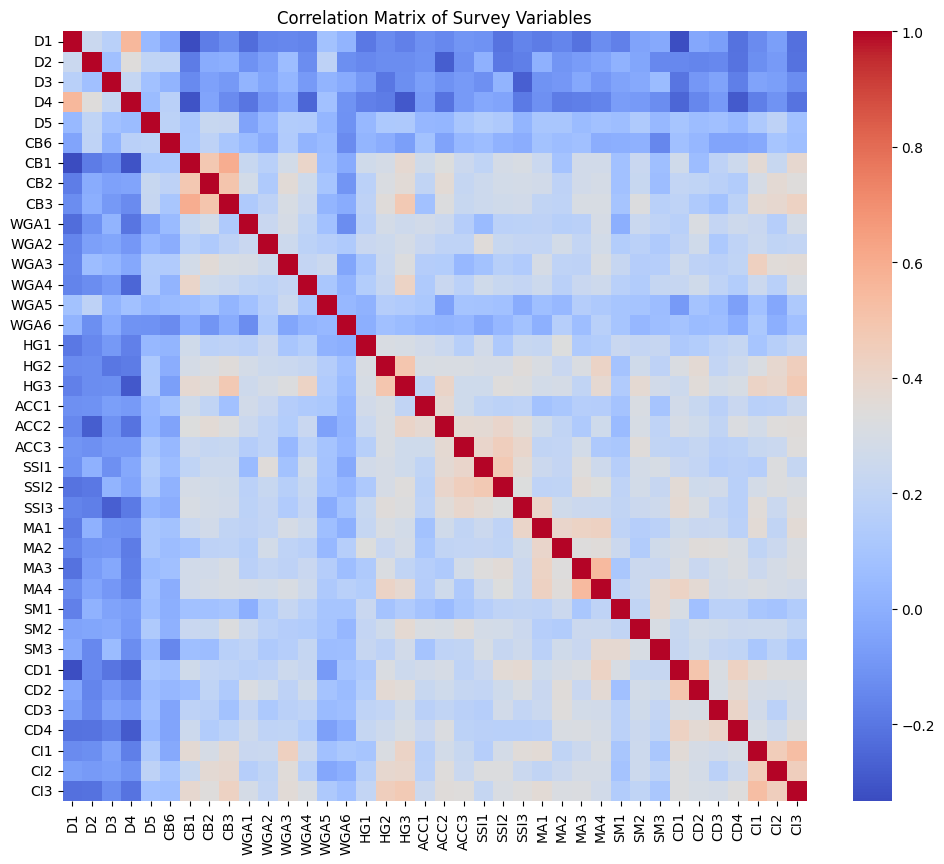

In [7]:
numeric_data = data.select_dtypes(include=np.number)
corr_matrix = numeric_data.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Survey Variables")
plt.show()

###KMO & Bartlett Test (Factor Suitability)

In [9]:
# Select only numeric data for KMO and Bartlett tests
numeric_data_for_tests = data.select_dtypes(include=np.number)

# KMO test
kmo_all, kmo_model = calculate_kmo(numeric_data_for_tests)
print("KMO Score:", kmo_model)

# Bartlett Test
chi_square_value, p_value = calculate_bartlett_sphericity(numeric_data_for_tests)
print("Bartlett Test Chi-square:", chi_square_value)
print("p-value:", p_value)

KMO Score: 0.8346424643912741
Bartlett Test Chi-square: 2708.14534302551
p-value: 2.186208356711942e-232


In [11]:
model_desc = """

# Measurement Model
Content_Behaviour =~ CB1 + CB2 + CB3
Watch_Gratification =~ WGA1 + WGA2 + WGA3 + WGA4 + WGA5 + WGA6
Habit_Generation =~ HG1 + HG2 + HG3
Accessibility =~ ACC1 + ACC2 + ACC3
Social_Motivation =~ SM1 + SM2 + SM3
Cost_Drivers =~ CD1 + CD2 + CD3 + CD4
Consumer_Intention =~ CI1 + CI2 + CI3

# Structural Model
Watch_Gratification ~ Content_Behaviour
Habit_Generation ~ Watch_Gratification
Consumer_Intention ~ Habit_Generation + Accessibility + Social_Motivation + Cost_Drivers

"""

In [12]:
model = Model(model_desc)

results = model.fit(data)

print(results)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 2.072
Number of iterations: 51
Params: 0.966 1.021 0.993 1.252 1.119 0.493 0.033 1.324 1.675 1.519 1.093 1.428 1.253 0.886 0.776 0.985 0.943 1.146 0.491 0.984 1.014 0.284 -0.530 0.424 0.989 0.844 0.966 0.345 0.361 0.283 0.186 0.743 0.978 0.722 0.603 0.703 0.934 0.855 0.703 0.898 0.621 0.115 0.776 0.353 0.581 1.569 0.725 0.577 0.024 1.129 0.772 0.900 0.244 0.234 0.248 1.192 1.300 1.070 1.006 1.536 0.243 0.068


In [13]:
estimates = model.inspect()

estimates.head(20)

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,Watch_Gratification,~,Content_Behaviour,0.490516,0.095414,5.140924,0.0
1,Habit_Generation,~,Watch_Gratification,0.984351,0.248636,3.959006,0.000075
2,Consumer_Intention,~,Habit_Generation,1.013955,0.249355,4.066309,0.000048
3,Consumer_Intention,~,Accessibility,0.283643,0.214222,1.324064,0.185482
4,Consumer_Intention,~,Social_Motivation,-0.529563,0.281879,-1.878687,0.060287
5,Consumer_Intention,~,Cost_Drivers,0.424206,0.148262,2.8612,0.00422
6,CB1,~,Content_Behaviour,1.000000,-,-,-
7,CB2,~,Content_Behaviour,0.965529,0.115936,8.328144,0.0
8,CB3,~,Content_Behaviour,1.020944,0.111743,9.136544,0.0
9,WGA1,~,Watch_Gratification,1.000000,-,-,-


In [14]:
from semopy import calc_stats

stats = calc_stats(model)

stats

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,263,300,439.365915,5.166667e-11,1616.531549,0.866037,0.728205,0.689967,0.728205,0.847191,0.056375,119.855039,327.963388,2.072481


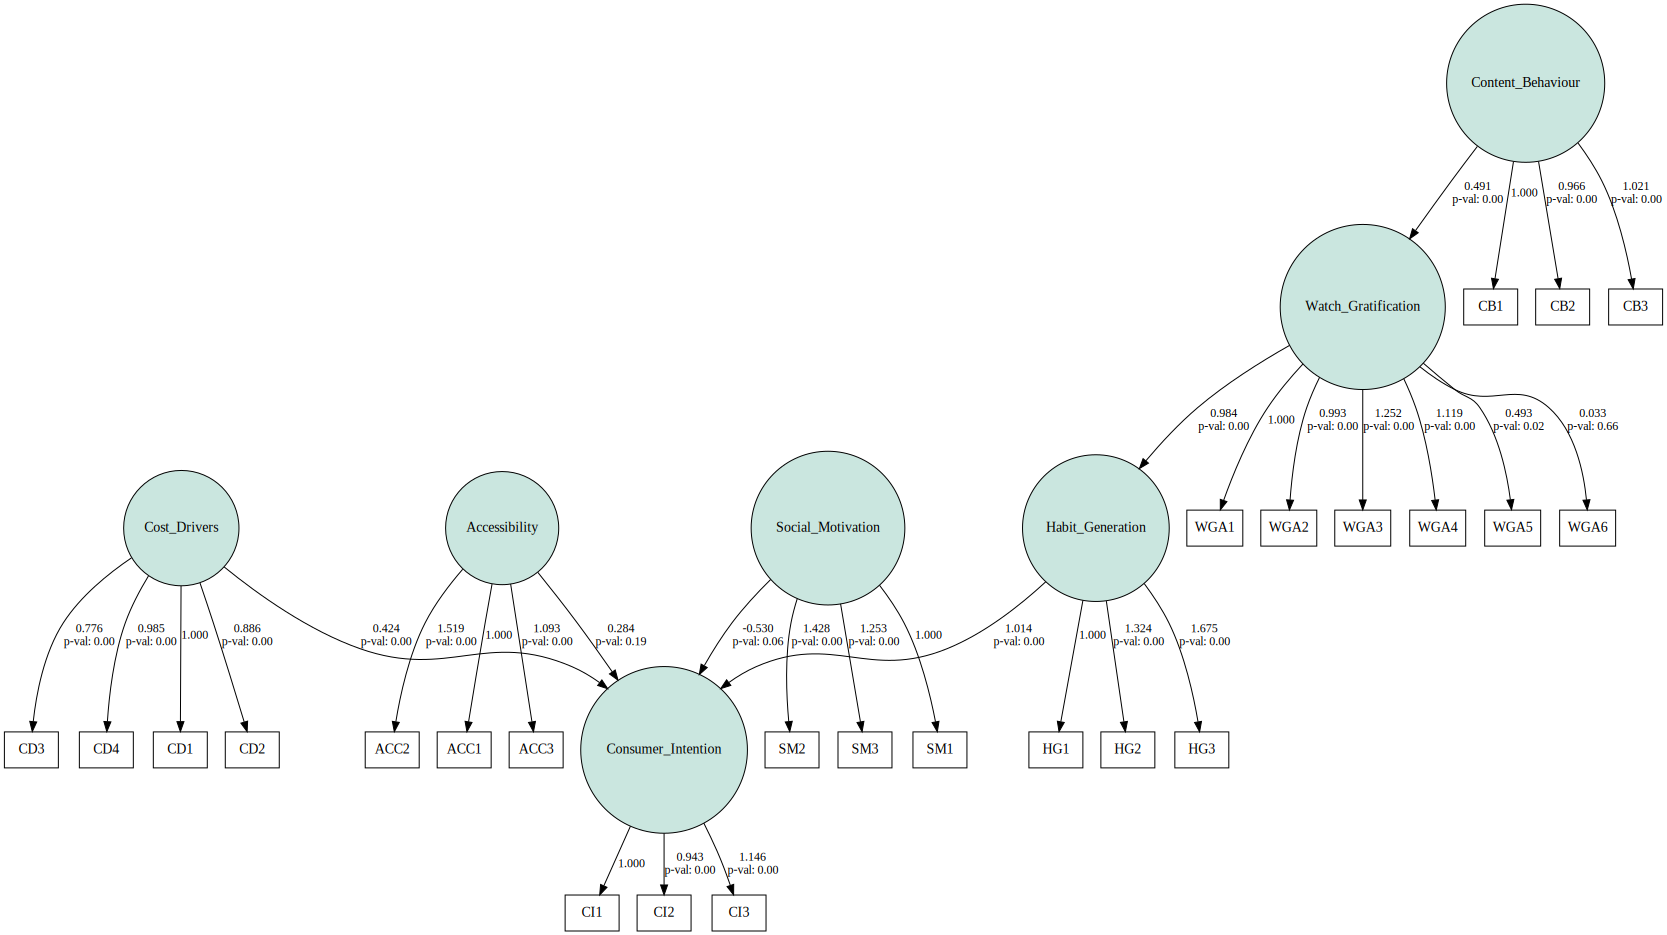

In [15]:
from semopy import semplot

semplot(model, "ott_sem_model.png")

Behavioral Insight Analysis

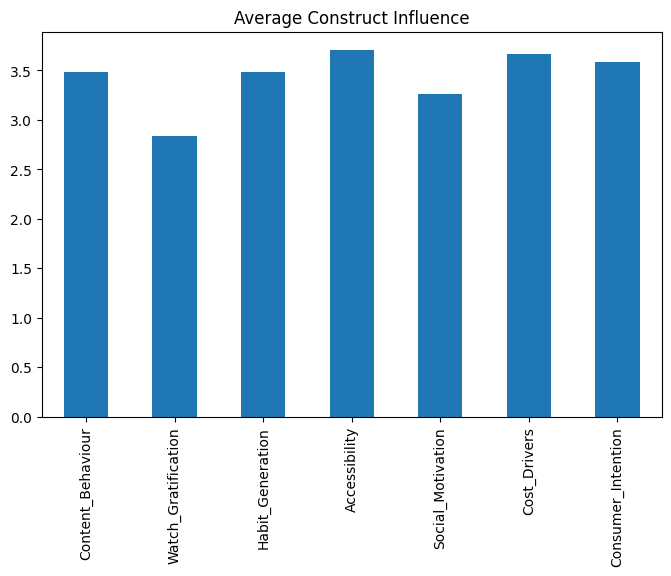

In [16]:
construct_means = pd.DataFrame({
    "Content_Behaviour": data[['CB1','CB2','CB3']].mean(axis=1),
    "Watch_Gratification": data[['WGA1','WGA2','WGA3','WGA4','WGA5','WGA6']].mean(axis=1),
    "Habit_Generation": data[['HG1','HG2','HG3']].mean(axis=1),
    "Accessibility": data[['ACC1','ACC2','ACC3']].mean(axis=1),
    "Social_Motivation": data[['SM1','SM2','SM3']].mean(axis=1),
    "Cost_Drivers": data[['CD1','CD2','CD3','CD4']].mean(axis=1),
    "Consumer_Intention": data[['CI1','CI2','CI3']].mean(axis=1)
})

construct_means.mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Construct Influence")
plt.show()